## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from wordcloud import WordCloud, STOPWORDS
import fitz  # PyMuPDF
from collections import Counter  # For word frequency counting
import textstat  # For readability indices


In [2]:
df = pd.DataFrame()
df = pd.read_csv("pdf_analysis.csv")

## WordCloud

Processing: AMEX_ATRS_2012.pdf
Processing: AMEX_ATRS_2013.pdf
Processing: AMEX_ATRS_2014.pdf
Processing: NASDAQ_AAIC_2020.pdf
Processing: NASDAQ_AAIC_2021.pdf
Processing: NASDAQ_AAIC_2022.pdf
Processing: NASDAQ_AAL_2019.pdf
Processing: NASDAQ_AAL_2020.pdf
Processing: NASDAQ_AAL_2021.pdf
Processing: NASDAQ_AAL_2022.pdf
Processing: NASDAQ_AAOI_2019.pdf
Processing: NASDAQ_AAOI_2020.pdf
Processing: NASDAQ_AAOI_2021.pdf
Processing: NASDAQ_AAOI_2022.pdf
Processing: NASDAQ_AAON_2019.pdf
Processing: NASDAQ_AAON_2020.pdf
Processing: NASDAQ_AAON_2021.pdf
Processing: NASDAQ_AAON_2022.pdf
Processing: NASDAQ_AAPL_2019.pdf
Processing: NASDAQ_AAPL_2020.pdf
Processing: NASDAQ_AAPL_2021.pdf
Processing: NASDAQ_AAPL_2022.pdf
Processing: NASDAQ_ABCB_2019.pdf
Processing: NASDAQ_ABCB_2020.pdf
Processing: NASDAQ_ABCB_2021.pdf
Processing: NASDAQ_ABCB_2022.pdf
Processing: NASDAQ_ABEO_2019.pdf
Processing: NASDAQ_ABEO_2020.pdf
Processing: NASDAQ_ABEO_2021.pdf
Processing: NASDAQ_ABEO_2022.pdf
Processing: NASDAQ_A

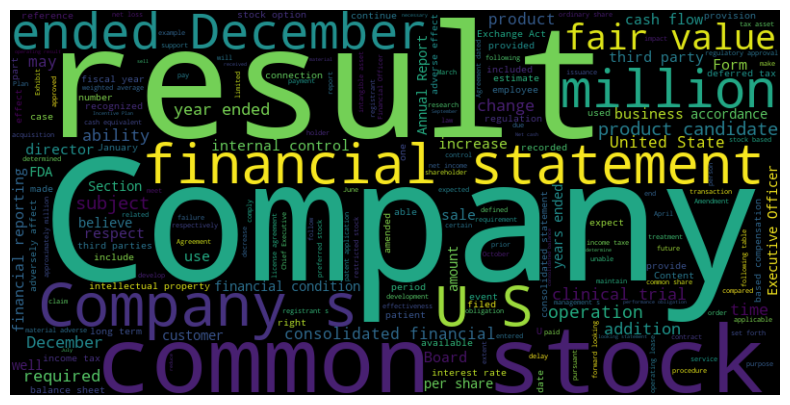

                File_Name                                               Text  \
0      AMEX_ATRS_2012.pdf  UNITED STATES \nSECURITIES AND EXCHANGE COMMIS...   
1      AMEX_ATRS_2013.pdf  UNITED STATES \nSECURITIES AND EXCHANGE COMMIS...   
2      AMEX_ATRS_2014.pdf   \n \n \nUNITED STATES \nSECURITIES AND EXCHAN...   
3    NASDAQ_AAIC_2020.pdf   \nUNITED STATES\nSECURITIES AND EXCHANGE COMM...   
4    NASDAQ_AAIC_2021.pdf   \nUNITED STATES\nSECURITIES AND EXCHANGE COMM...   
..                    ...                                                ...   
982    NASDAQ_YI_2019.pdf  Table of Contents\n \nUNITED STATES\nSECURITIE...   
983    NASDAQ_YI_2020.pdf  Table of Contents\nUNITED STATES\nSECURITIES A...   
984    NASDAQ_YI_2021.pdf  Table of Contents\nUNITED STATES\n\nSECURITIES...   
985      NYSE_AI_2019.pdf   \nUNITED STATES\nSECURITIES AND EXCHANGE COMM...   
986      TSX_DOO_2017.pdf  2017 ANNUAL REVIEW\nFueling growth  \nwith inn...   

     Page_Count  File_Size_KB  Word_Cou

In [3]:
# Function to extract text and other information from a PDF file using PyMuPDF
def analyze_pdf(pdf_path):
    try:
        doc = fitz.open(pdf_path)
        text = ""
        for page in doc:
            text += page.get_text()

        page_count = doc.page_count
        file_size_kb = os.path.getsize(pdf_path) / 1024  # File size in KB
        word_count = len(text.split())

        return {
            "File_Name": os.path.basename(pdf_path),  # Just filename
            "Text": text,  # Include the text if you need it for other analysis
            "Page_Count": page_count,
            "File_Size_KB": file_size_kb,
            "Word_Count": word_count
        }
    except Exception as e:
        print(f"Error processing {pdf_path}: {e}")  # Handle exceptions
        return None  # Or return None if you prefer


# Define a list of keywords
keywords = [
    "revenue", "income", "expense", "profit", "loss", "asset", "liability",
    "equity", "cash flow", "debt", "interest", "shareholder", "dividend",
    "ratio", "margin", "return", "risk", "investment", "financial statement"
]

# Create an empty DataFrame
df = pd.DataFrame()  # No columns pre-defined

# Specify the directory containing your PDF files
pdf_directory = "Data"  # Replace with the actual path

# Iterate through each PDF file in the directory
for filename in os.listdir(pdf_directory):
    if filename.endswith(".pdf"):
        filepath = os.path.join(pdf_directory, filename)
        print(f"Processing: {filename}")  # Indicate which file is being processed
        analysis_results = analyze_pdf(filepath)

        if analysis_results:  # Check if analysis was successful
            df = pd.concat([df, pd.DataFrame([analysis_results])], ignore_index=True)

# Basic text analysis
if not df.empty: #Check if there is any text to process
    df["Keyword_Count"] = df["Text"].apply(lambda x: sum(x.lower().count(keyword) for keyword in keywords))

    # Word cloud visualization (optional)
    text_all = " ".join(df["Text"].tolist())
    wordcloud = WordCloud(width=800, height=400, stopwords=STOPWORDS).generate(text_all)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()
else:
    print("No text extracted to generate wordcloud.")


print(df)  # Print the dataframe for review
df.to_csv('pdf_analysis.csv', index=False)  # Save to a csv file

We started analyzing the data by looking at the most common words.  First, we made a word cloud to get a quick visual idea of what words popped up most often.  Then, we created a DataFrame to get more specific. This table showed how many times each word appeared.  We were especially interested in a specific set of words, so we counted how many times those words showed up.  By comparing how often these specific words appeared to how often words usually appear, we could see if they were noticeably more common than the average word.  This helped us understand the main topics and themes in the data.

In [6]:
def extract_company_name_from_filename(filename):
    match = re.match(r"NASDAQ_([^_]+)_\d+", filename)  # More specific regex
    if match:
        return match.group(1).strip()  # Extract the name (group 1)
    return None

folder_path = "Data"
pdf_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".pdf")]

all_companies = []
for pdf_file in pdf_files:
    company_name = extract_company_name_from_filename(pdf_file)
    if company_name:
        all_companies.append(company_name)

unique_companies = set(all_companies)
print(f"Number of unique companies found: {len(unique_companies)}")

# (Optional) Save to file:
with open("unique_companies.txt", "w", encoding="utf-8") as f:
    for company in unique_companies:
        f.write(company + "\n")

print("There was around 1.2K comanies in 2022, now that number is more than 7K")

Number of unique companies found: 244
There was around 1.2K comanies in 2022, now that number is more than 7K


As shown, this is the reality of the dataset, we have a limited grasp of the companies since there is way too many of them to just include all of them in the dataset.

## Distributions

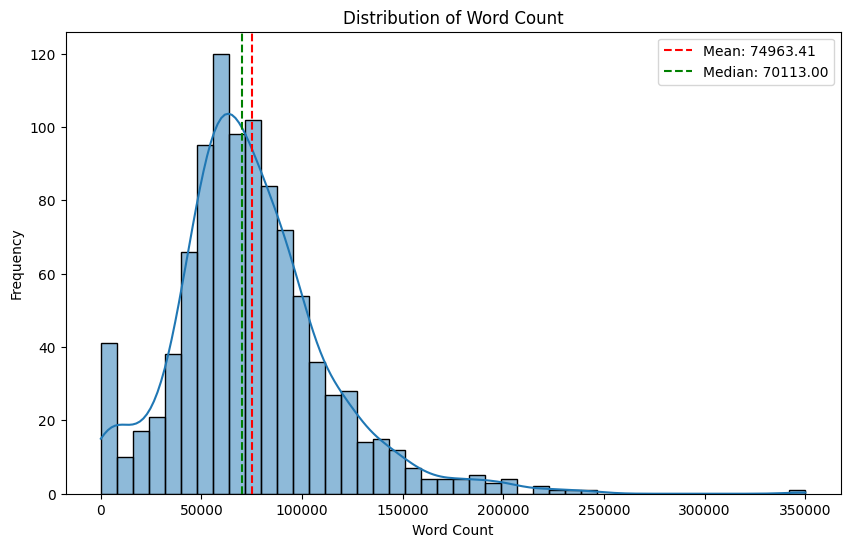

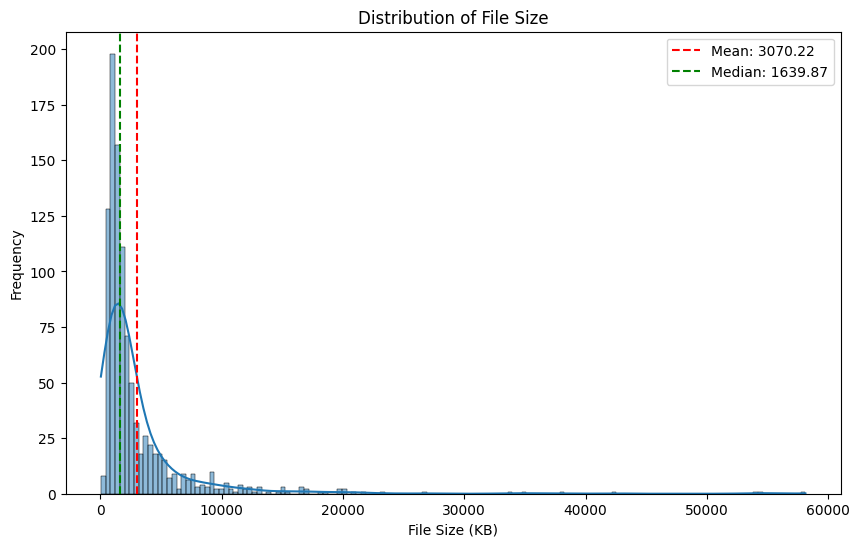

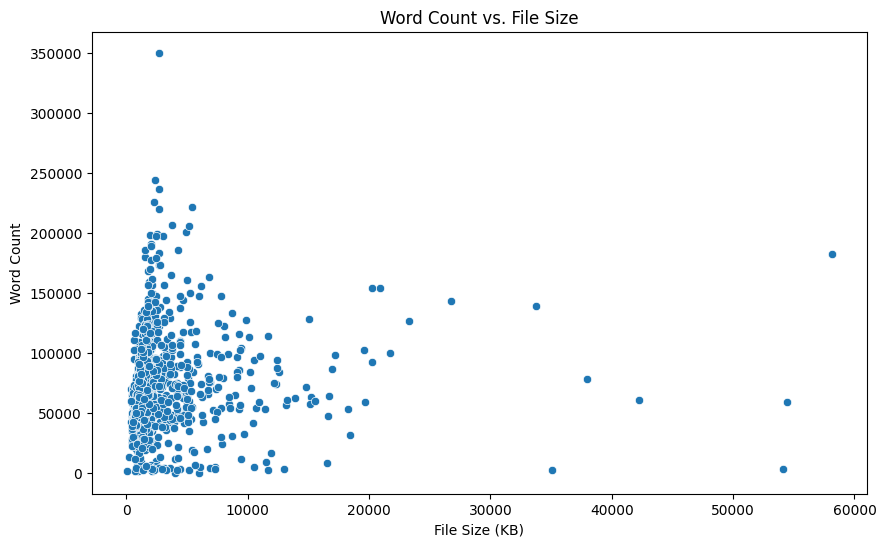

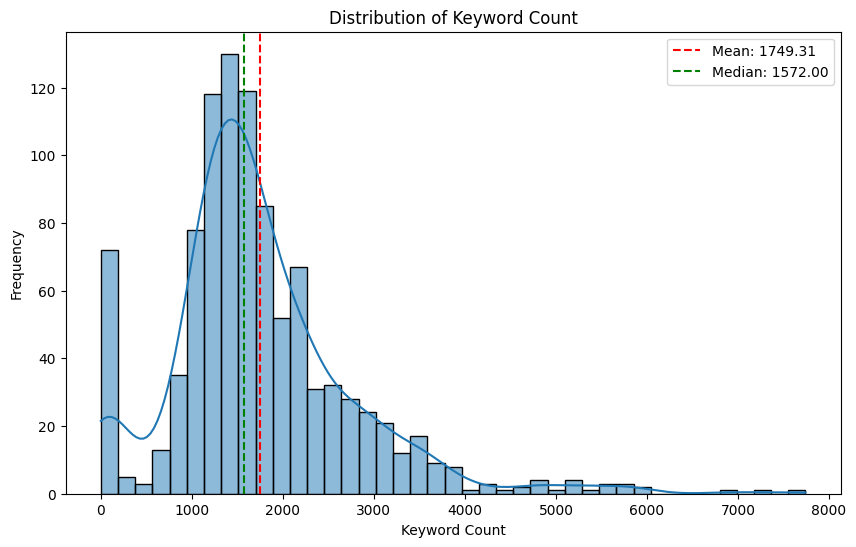

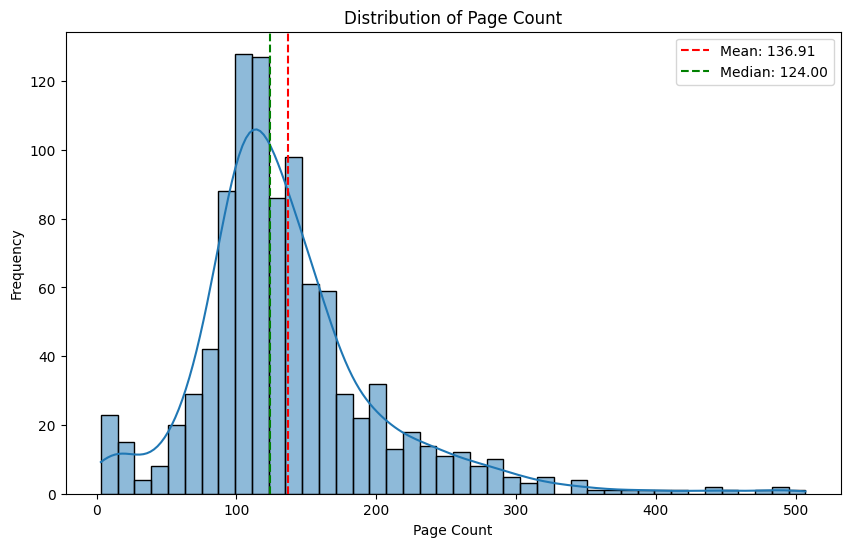

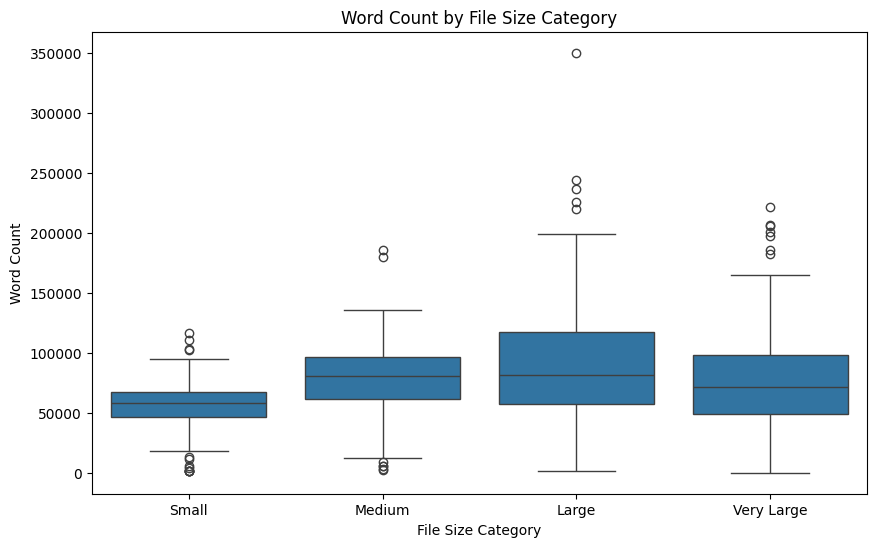

In [3]:
# Plotting with Matplotlib and Seaborn

if not df.empty:

    # 1. Distribution of Word Count:
    plt.figure(figsize=(10, 6))
    sns.histplot(df["Word_Count"], kde=True)
    mean_word_count = df["Word_Count"].mean()
    median_word_count = df["Word_Count"].median()
    plt.axvline(mean_word_count, color='r', linestyle='--', label=f'Mean: {mean_word_count:.2f}')
    plt.axvline(median_word_count, color='g', linestyle='--', label=f'Median: {median_word_count:.2f}')
    plt.title("Distribution of Word Count")
    plt.xlabel("Word Count")
    plt.ylabel("Frequency")
    plt.legend()  # Show the legend
    plt.show()

    # 2. Distribution of File Size:
    plt.figure(figsize=(10, 6))
    sns.histplot(df["File_Size_KB"], kde=True)
    mean_file_size = df["File_Size_KB"].mean()
    median_file_size = df["File_Size_KB"].median()
    plt.axvline(mean_file_size, color='r', linestyle='--', label=f'Mean: {mean_file_size:.2f}')
    plt.axvline(median_file_size, color='g', linestyle='--', label=f'Median: {median_file_size:.2f}')
    plt.title("Distribution of File Size")
    plt.xlabel("File Size (KB)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    # 3. Word Count vs. File Size:  (Scatter plot - mean/median less relevant here)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x="File_Size_KB", y="Word_Count", data=df)
    plt.title("Word Count vs. File Size")
    plt.xlabel("File Size (KB)")
    plt.ylabel("Word Count")
    plt.show()

    # 4. Keyword Count Distribution:
    plt.figure(figsize=(10, 6))
    sns.histplot(df["Keyword_Count"], kde=True)
    mean_keyword_count = df["Keyword_Count"].mean()
    median_keyword_count = df["Keyword_Count"].median()
    plt.axvline(mean_keyword_count, color='r', linestyle='--', label=f'Mean: {mean_keyword_count:.2f}')
    plt.axvline(median_keyword_count, color='g', linestyle='--', label=f'Median: {median_keyword_count:.2f}')
    plt.title("Distribution of Keyword Count")
    plt.xlabel("Keyword Count")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    # 5. Page Count Distribution:
    plt.figure(figsize=(10, 6))
    sns.histplot(df["Page_Count"], kde=True)
    mean_page_count = df["Page_Count"].mean()
    median_page_count = df["Page_Count"].median()
    plt.axvline(mean_page_count, color='r', linestyle='--', label=f'Mean: {mean_page_count:.2f}')
    plt.axvline(median_page_count, color='g', linestyle='--', label=f'Median: {median_page_count:.2f}')
    plt.title("Distribution of Page Count")
    plt.xlabel("Page Count")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    # 6. Box Plot of Word Count by File Size Category: (Box plots already show median)
    df["File_Size_Category"] = pd.qcut(df["File_Size_KB"], q=4, labels=["Small", "Medium", "Large", "Very Large"])
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="File_Size_Category", y="Word_Count", data=df)
    plt.title("Word Count by File Size Category")
    plt.xlabel("File Size Category")
    plt.ylabel("Word Count")
    plt.show()

    # ... (Word cloud generation remains the same)

else:
    print("No data to generate plots.")




The graphs explore characteristics of text data, including word counts, file sizes, keyword counts, and page counts.  The histograms reveal how these variables are distributed, showing if they cluster around a central value or are skewed.  In all of these distributions, the mean is higher than the median, suggesting a positive skew. This indicates that while most values are relatively low, there are some significantly higher values pulling the mean upwards. The scatter plot of word count versus file size visualizes the relationship between these two factors, showing if larger files tend to have more words. Finally, the box plot compares word count distributions across different file size categories, allowing us to see how word counts vary from small to very large files in which we can notice that there isn't a noticeable difference, it's easily seen that those metrics don't share a direct correlation.

## Most common words

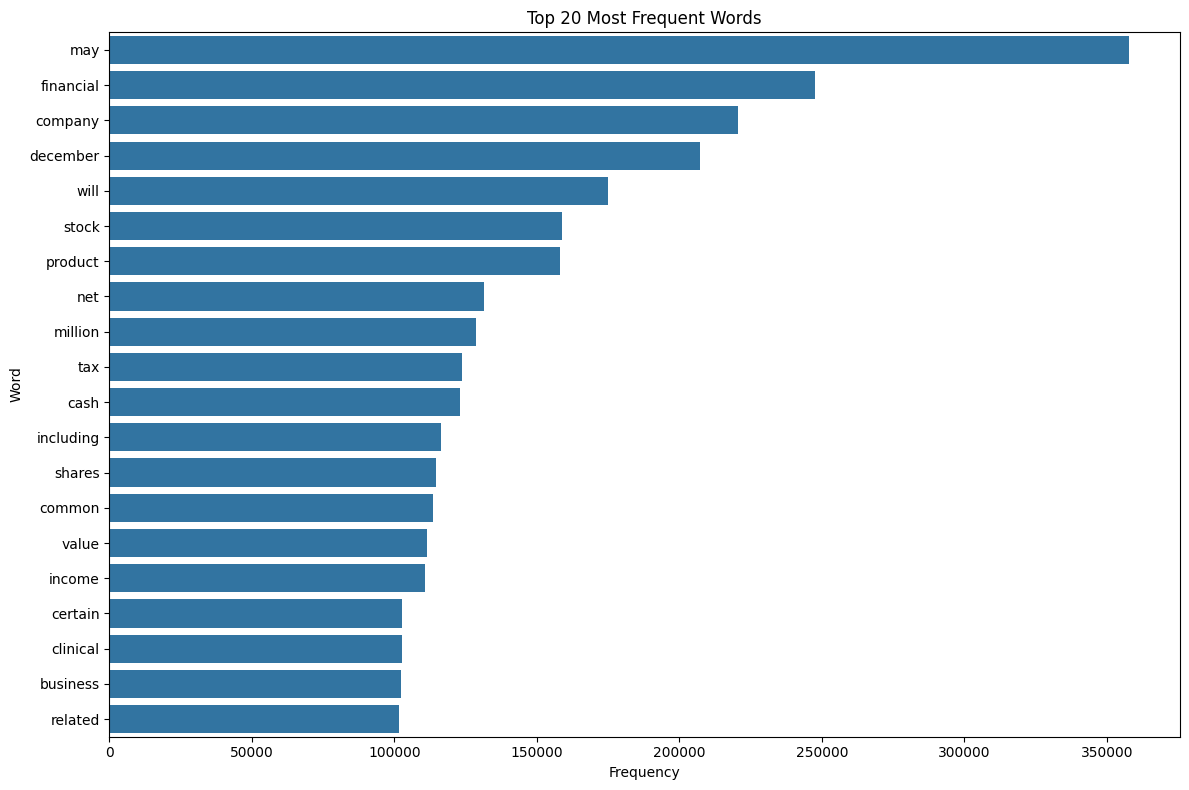

In [6]:
if not df.empty:
    # Drop rows with NaN in "Text" column before processing
    df_cleaned = df.dropna(subset=["Text"]).copy()  # Create a copy to avoid SettingWithCopyWarning

    if not df_cleaned.empty:  # Check if there is text to process
        all_text = " ".join(df_cleaned["Text"].astype(str).tolist()) # Convert to string in case of other type errors.
        # wordcloud = WordCloud(width=800, height=400, stopwords=STOPWORDS).generate(all_text)
        # plt.figure(figsize=(10, 5))
        # plt.imshow(wordcloud, interpolation='bilinear')
        # plt.axis("off")
        # plt.title("Word Cloud of All Text")
        # plt.show()

        # Most Frequent Words (Bar Chart):
        word_counts = Counter()

        for text in df_cleaned["Text"]:
            words = text.lower().split()
            words = [word for word in words if word not in STOPWORDS and word.isalnum()]
            word_counts.update(words)

        most_common_words = word_counts.most_common(20)

        word_labels = [word[0] for word in most_common_words]
        word_frequencies = [word[1] for word in most_common_words]

        plt.figure(figsize=(12, 8))
        sns.barplot(x=word_frequencies, y=word_labels)
        plt.title("Top 20 Most Frequent Words")
        plt.xlabel("Frequency")
        plt.ylabel("Word")
        plt.tight_layout()
        plt.show()

        # ... other plots (using df_cleaned if needed) ...

    else:
        print("No text extracted to generate wordcloud or frequency chart.")

else:
    print("No data to generate plots.")

This is a basic list of the most common words, and the top is "may". This word reveals a key aspect of the dataset's nature, as in the financial world, even the experts have to work on assumptions and might not know what the future holds.

## Readability

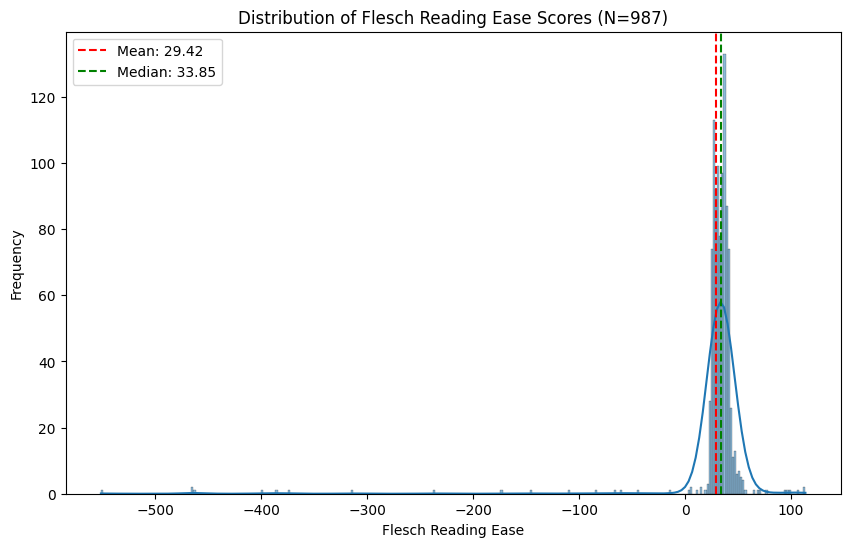

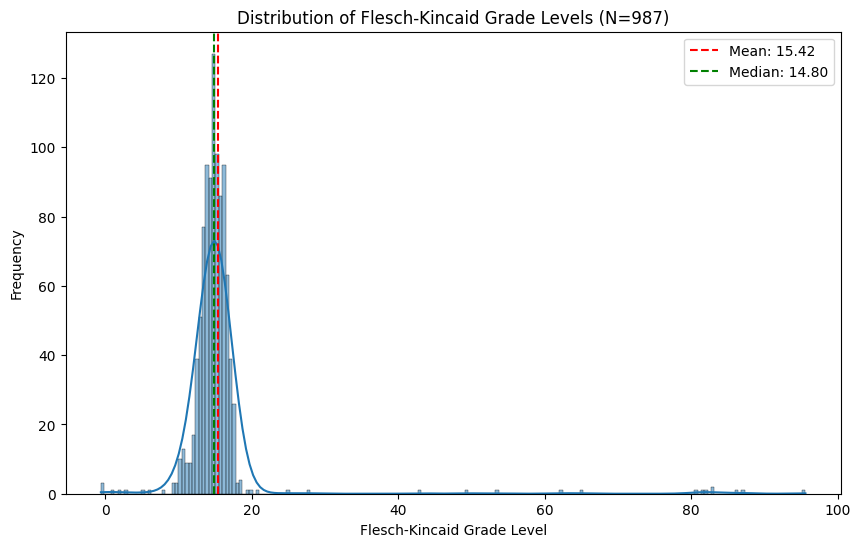

In [4]:
def calculate_readability(text):
    try:
        if not text: #Check if the text is empty
            return None #Return None if there is no text to avoid errors
        flesch_reading_ease = textstat.flesch_reading_ease(text)
        flesch_kincaid_grade = textstat.flesch_kincaid_grade(text)
        smog_index = textstat.smog_index(text)
        coleman_liau_index = textstat.coleman_liau_index(text)
        automated_readability_index = textstat.automated_readability_index(text)
        dale_chall_readability_score = textstat.dale_chall_readability_score(text)

        return {
            "Flesch_Reading_Ease": flesch_reading_ease,
            "Flesch_Kincaid_Grade": flesch_kincaid_grade,
            "SMOG_Index": smog_index,
            "Coleman_Liau_Index": coleman_liau_index,
            "Automated_Readability_Index": automated_readability_index,
            "Dale_Chall_Readability_Score": dale_chall_readability_score,
        }
    except Exception as e:
        print(f"Error calculating readability: {e}")  # Handle exceptions
        return None

if not df.empty:
    df_cleaned = df.dropna(subset=["Text"]).copy()

    if not df_cleaned.empty:
        # Calculate readability indices
        readability_results = df_cleaned["Text"].apply(calculate_readability)
        df_cleaned = pd.concat([df_cleaned, readability_results.apply(pd.Series)], axis=1)

        # --- Plotting with Analysis Annotations ---

        # 1. Flesch Reading Ease
        plt.figure(figsize=(10, 6))
        ax = sns.histplot(df_cleaned["Flesch_Reading_Ease"].dropna(), kde=True)

        # Add analysis annotations
        mean_score = df_cleaned["Flesch_Reading_Ease"].mean()
        median_score = df_cleaned["Flesch_Reading_Ease"].median()
        plt.axvline(mean_score, color='r', linestyle='--', label=f'Mean: {mean_score:.2f}')
        plt.axvline(median_score, color='g', linestyle='--', label=f'Median: {median_score:.2f}')

        plt.title(f"Distribution of Flesch Reading Ease Scores (N={len(df_cleaned)})") # Add N value
        plt.xlabel("Flesch Reading Ease")
        plt.ylabel("Frequency")
        plt.legend() # Show the legend
        plt.show()

        # 2. Flesch-Kincaid Grade Level
        plt.figure(figsize=(10, 6))
        ax = sns.histplot(df_cleaned["Flesch_Kincaid_Grade"].dropna(), kde=True)

         # Add analysis annotations
        mean_score = df_cleaned["Flesch_Kincaid_Grade"].mean()
        median_score = df_cleaned["Flesch_Kincaid_Grade"].median()
        plt.axvline(mean_score, color='r', linestyle='--', label=f'Mean: {mean_score:.2f}')
        plt.axvline(median_score, color='g', linestyle='--', label=f'Median: {median_score:.2f}')

        plt.title(f"Distribution of Flesch-Kincaid Grade Levels (N={len(df_cleaned)})") # Add N value
        plt.xlabel("Flesch-Kincaid Grade Level")
        plt.ylabel("Frequency")
        plt.legend() # Show the legend
        plt.show()

    else:
        print("No text extracted to calculate readability.")
else:
    print("No data to generate plots.")

A low Flesch Reading Ease score indicates that text is difficult to read and understand, likely containing long sentences, complex vocabulary, and abstract concepts. Conversely, a high Flesch-Kincaid Grade Level score suggests the text is written at a level appropriate for that grade level. For example, a Flesch-Kincaid score of 10 means the text is generally understandable for someone with a 10th-grade reading level. In this case you might need in average more than a professional degree to fully grasp all of the documents' contents.